# 2. Análisis Univariado
---

### 1. Introducción

Este notebook profundiza el análisis individual de cada variable relevante de los datos `freMTPL2freq` y `freMTPL2sev`.

### 2. Objetivo del análisis univariado

Comprender, para cada variable de interés, su tendencia central, dispersión, forma de
distribución y posibles valores atípicos, **antes** de avanzar hacia el análisis
bivariado/multivariado y la modelación actuarial. 


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

%load_ext autoreload
%autoreload 2

sys.path.append(str(Path("..").resolve()))
from src.utils import set_plot_style, load_freq, load_sev, hist_box, tabla_frecuencias, ecdf

set_plot_style()
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

df_freq = load_freq("freMTPL2freq.csv")
df_sev = load_sev("freMTPL2sev.csv")



### 3. Variables numéricas

Para cada variable numérica se presenta un resumen estadístico (tendencia central,
dispersión, percentiles, rango intercuartílico y asimetría), acompañado de un
histograma con KDE, un boxplot y, en los casos donde aporta valor adicional, la función
de distribución empírica (ECDF).


In [2]:
def resumen_univariado(serie, nombre):
    """Calcula un resumen estadistico univariado estandar para una variable numerica."""
    return pd.Series({
        "n": serie.shape[0],
        "media": serie.mean(),
        "mediana": serie.median(),
        "desv_estandar": serie.std(),
        "minimo": serie.min(),
        "p1": serie.quantile(0.01),
        "q1": serie.quantile(0.25),
        "q3": serie.quantile(0.75),
        "p99": serie.quantile(0.99),
        "maximo": serie.max(),
        "rango_intercuartilico": serie.quantile(0.75) - serie.quantile(0.25),
        "asimetria": stats.skew(serie.dropna()),
    }, name=nombre)


#### 3.1 Exposure
La variable Exposure representa la fracción del año durante la cual cada póliza estuvo asegurada.

In [3]:
resumen_univariado(df_freq["Exposure"], "Exposure").to_frame()

,Exposure
n,"678,007.0000"
media,0.5285
mediana,0.4900
desv_estandar,0.3641
minimo,0.0027
p1,0.0082
q1,0.1800
q3,0.9900
p99,1.0000
maximo,1.0000


c:\Users\User\.conda\envs\dataviz_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


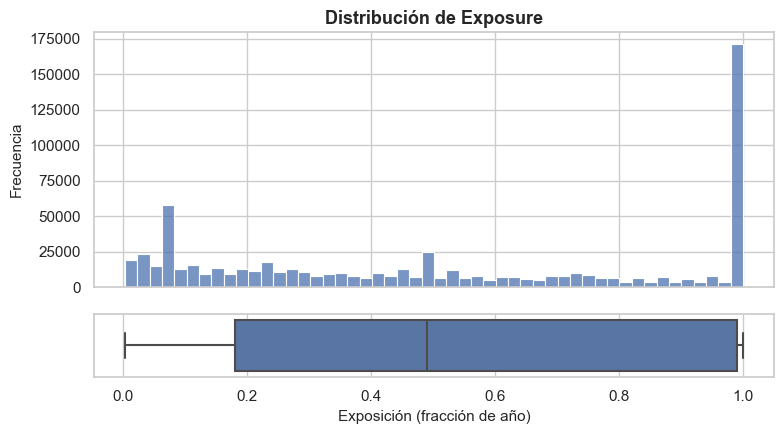

In [4]:
hist_box(df_freq["Exposure"], titulo="Distribución de Exposure",
         xlabel="Exposición (fracción de año)", bins=50, color="#4C72B0")



**Interpretación de Exposure**

La media es de 0.5285 años y la mediana de 0.49, por lo que, en general, las pólizas tienen una exposición cercana a medio año.

En el gráfico se observa una concentración bastante alta de pólizas con una exposición cercana a 1 año. Esto indica que muchas pólizas estuvieron activas durante prácticamente todo el período de observación. También hay pólizas con tiempos de exposición más cortos, llegando incluso a valores cercanos a cero.

La distribución presenta una asimetría positiva muy leve (0.0816), por lo que no se observa un sesgo importante. Además, los valores se encuentran dentro del rango esperado de 0 a 1 y el boxplot no muestra valores atípicos relevantes.

Esta variable será importante más adelante porque permite tener en cuenta cuánto tiempo estuvo cada póliza expuesta al riesgo al analizar la cantidad de siniestros.


#### 3.2 VehAge
La variable VehAge representa la antigüedad del vehículo en años.

In [5]:
resumen_univariado(df_freq["VehAge"], "VehAge").to_frame()

,VehAge
n,"678,007.0000"
media,7.0442
mediana,6.0000
desv_estandar,5.6662
minimo,0.0000
p1,0.0000
q1,2.0000
q3,11.0000
p99,21.0000
maximo,100.0000


c:\Users\User\.conda\envs\dataviz_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


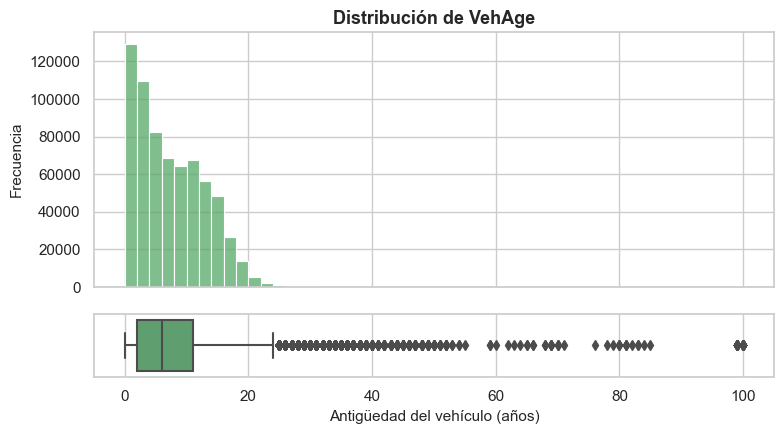

In [6]:
hist_box(df_freq["VehAge"], titulo="Distribución de VehAge",
         xlabel="Antigüedad del vehículo (años)", bins=50, color="#55A868")


**Interpretación de VehAge**


 La mediana es de 6 años y la media de 7.04, por lo que la mayoría de los vehículos se encuentran aproximadamente entre los primeros años de antigüedad. El 50% central de los datos está entre 2 y 11 años.

En el gráfico se observa una concentración bastante alta de vehículos jóvenes y la frecuencia disminuye a medida que aumenta la antigüedad. La distribución presenta una asimetría positiva (1.15), debido a la presencia de algunos vehículos mucho más antiguos.

El boxplot muestra varios valores potencialmente atípicos por encima de los 20 años, llegando incluso hasta los 100 años. Estos valores llaman especialmente la atención y deberían revisarse posteriormente para determinar si corresponden a casos reales o a posibles errores en los datos.


#### 3.3 DrivAge
La variable DrivAge representa la edad del conductor.

In [7]:
resumen_univariado(df_freq["DrivAge"], "DrivAge").to_frame()

,DrivAge
n,"678,007.0000"
media,45.4991
mediana,44.0000
desv_estandar,14.1375
minimo,18.0000
p1,20.0000
q1,34.0000
q3,55.0000
p99,80.0000
maximo,100.0000


c:\Users\User\.conda\envs\dataviz_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


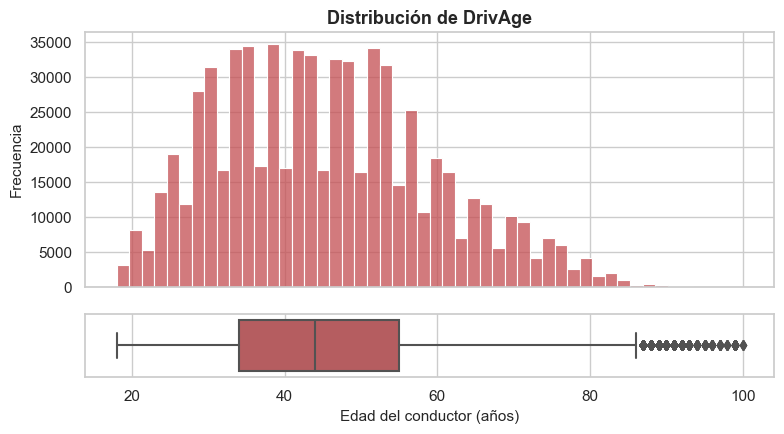

In [8]:
hist_box(df_freq["DrivAge"], titulo="Distribución de DrivAge",
         xlabel="Edad del conductor (años)", bins=50, color="#C44E52")


**Interpretación de DrivAge.**

 La media es de 45.5 años y la mediana de 44 años, por lo que la edad de los conductores se concentra principalmente alrededor de los 40 y 50 años. El 50% central de los datos se encuentra entre 34 y 55 años.

En el gráfico se observa una mayor concentración de conductores entre aproximadamente los 30 y 60 años, mientras que las frecuencias disminuyen en las edades más altas. La distribución presenta una ligera asimetría hacia la derecha (0.44).

El boxplot muestra algunos valores potencialmente atípicos en las edades superiores, principalmente por encima de los 85 años, llegando hasta los 100 años. Estos valores deberán revisarse posteriormente, aunque no necesariamente representan errores, ya que pueden corresponder a conductores de edades avanzadas.


#### 3.4 BonusMalus
Factor utilizado para ajustar la prima según el historial de siniestralidad del conductor. Valores más altos generalmente representan un mayor nivel de riesgo.

In [9]:
resumen_univariado(df_freq["BonusMalus"], "BonusMalus").to_frame()

,BonusMalus
n,"678,007.0000"
media,59.7616
mediana,50.0000
desv_estandar,15.6367
minimo,50.0000
p1,50.0000
q1,50.0000
q3,64.0000
p99,106.0000
maximo,230.0000


c:\Users\User\.conda\envs\dataviz_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


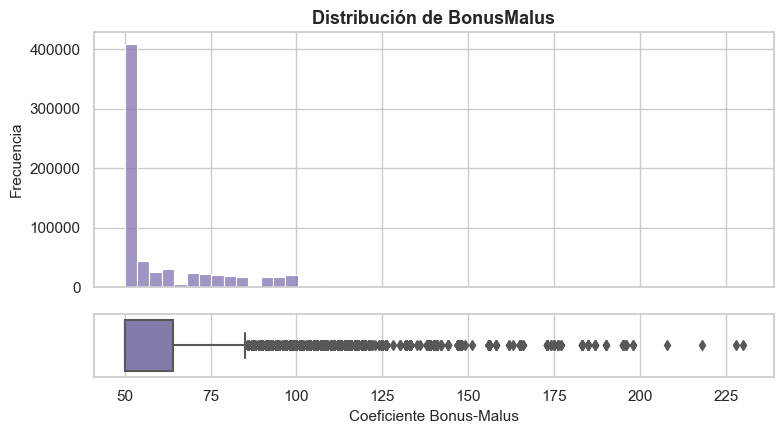

In [10]:
hist_box(df_freq["BonusMalus"], titulo="Distribución de BonusMalus",
         xlabel="Coeficiente Bonus-Malus", bins=50, color="#8172B2")


**Interpretación de BonusMalus**

La variable BonusMalus presenta una concentración muy marcada en el valor 50, que corresponde también a la mediana. A partir de este valor, la cantidad de observaciones disminuye, aunque se mantienen valores cada vez más altos.

La media es de 59.76, superior a la mediana, lo que se explica por la presencia de valores altos. Esto también se refleja en la asimetría positiva (1.73). El boxplot muestra una gran cantidad de valores potencialmente atípicos por encima de aproximadamente 85, llegando hasta 230.

En general, la variable está muy concentrada en valores bajos, principalmente alrededor de 50, pero presenta una cola larga hacia valores altos. Estos valores extremos deberían revisarse posteriormente para determinar si corresponden a casos reales o a posibles problemas en los datos.


#### 3.5 Density
La variable Density representa la densidad de población de la zona donde vive el asegurado, medida en habitantes por km².

In [11]:
resumen_univariado(df_freq["Density"], "Density").to_frame()

,Density
n,"678,007.0000"
media,"1,792.4310"
mediana,393.0000
desv_estandar,"3,958.6630"
minimo,1.0000
p1,10.0000
q1,92.0000
q3,"1,658.0000"
p99,"27,000.0000"
maximo,"27,000.0000"


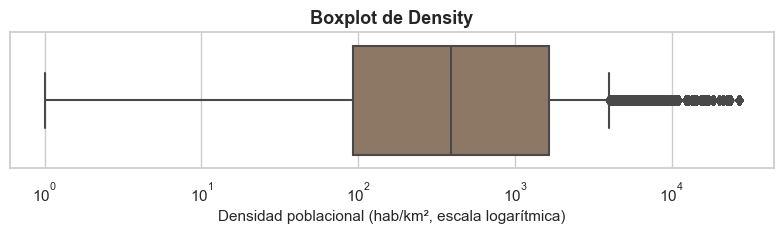

In [12]:
plt.figure(figsize=(8, 2.5))

sns.boxplot(
    x=df_freq["Density"],
    color="#937860"
)

plt.xscale("log")
plt.title("Boxplot de Density")
plt.xlabel("Densidad poblacional (hab/km², escala logarítmica)")

plt.tight_layout()
plt.show()


**Interpretación de Density.**
La mediana es de 393 habitantes/km², mientras que la media es mucho mayor (1.792 habitantes/km²), lo que se debe a la presencia de algunas zonas con densidades muy altas. En el gráfico se observa una fuerte concentración de valores bajos y una cola larga hacia la derecha. La asimetría es bastante alta (4.65), por lo que la distribución está claramente sesgada hacia valores grandes.

El boxplot muestra una gran cantidad de valores potencialmente atípicos en la parte superior, especialmente por encima de aproximadamente 4.000 habitantes/km², llegando hasta 27.000 habitantes/km². 


#### 3.6 Variable objetivo para la severidad: **ClaimAmount**
La variable ClaimAmount representa el monto de cada siniestro.

In [13]:
resumen_univariado(df_sev["ClaimAmount"], "ClaimAmount").to_frame()

,ClaimAmount
n,"24,938.0000"
media,"2,397.0479"
mediana,"1,172.0000"
desv_estandar,"30,266.6188"
minimo,1.0000
p1,39.8751
q1,749.2625
q3,"1,346.3600"
p99,"17,960.2374"
maximo,"4,075,400.5600"


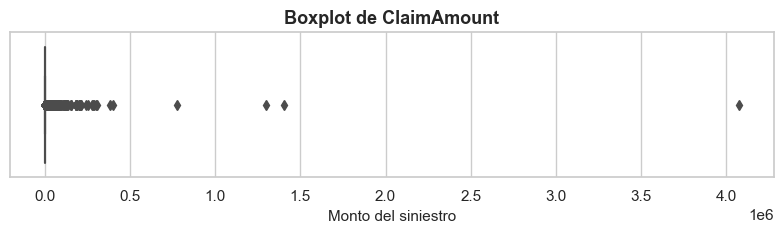

In [14]:
plt.figure(figsize=(8, 2.5))

sns.boxplot(
    x=df_sev["ClaimAmount"],
    color="#4C72B0"
)

plt.title("Boxplot de ClaimAmount")
plt.xlabel("Monto del siniestro")

plt.tight_layout()
plt.show()

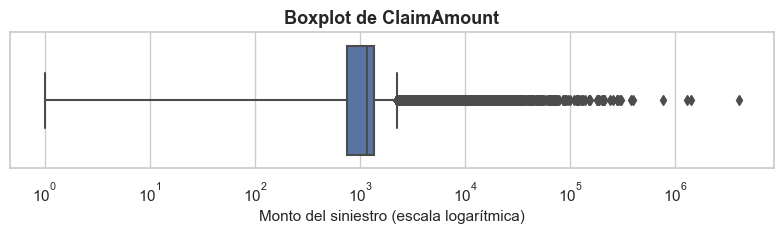

In [15]:
plt.figure(figsize=(8, 2.5))

sns.boxplot(
    x=df_sev["ClaimAmount"],
    color="#4C72B0"
)

plt.xscale("log")
plt.title("Boxplot de ClaimAmount")
plt.xlabel("Monto del siniestro (escala logarítmica)")

plt.tight_layout()
plt.show()


**Interpretación de ClaimAmount**

ClaimAmount representa el monto de cada siniestro. Se observa una diferencia importante entre la media y la mediana: la media es de aproximadamente **2.397**, mientras que la mediana es de **1.172**. Esto indica que algunos siniestros de valores muy altos están elevando la media.

El 50% central de los siniestros se encuentra aproximadamente entre **749 y 1.346**, mientras que el 99% de los valores es inferior a **17.960**. Sin embargo, existen algunos casos con montos mucho mayores, llegando hasta **4.075.400**, lo que explica la fuerte asimetría positiva de la variable (**106.14**).

Para visualizar mejor esta distribución se utiliza una **escala logarítmica en el eje X**, ya que los montos presentan diferencias de varios órdenes de magnitud. En el boxplot se observa una gran cantidad de valores por encima del límite superior, especialmente hacia los montos más altos.

Estos valores extremos no se consideran automáticamente errores, ya que en el contexto de seguros pueden corresponder a siniestros reales de alto costo. Por esta razón, se mantienen en esta etapa exploratoria y su tratamiento se evaluará posteriormente durante el preprocesamiento y la modelación de severidad.


### 4. Variables categóricas

Se analiza, para cada variable categórica relevante de `freMTPL2freq`, el número de
categorías, la frecuencia absoluta y relativa, la categoría más frecuente y, cuando
corresponde, la menos frecuente. Para variables con muchas categorías se muestran
únicamente las principales, indicándolo explícitamente.


#### 4.1 Variables Area y VehGas


In [16]:
for col in ["Area", "VehGas"]:
    print(f"\n--- {col} ({df_freq[col].nunique()} categorías) ---")
    display(tabla_frecuencias(df_freq, col))



--- Area (6 categorías) ---


,frecuencia_absoluta,frecuencia_relativa_%
Area,,
C,191880,28.3000
D,151590,22.3600
E,137167,20.2300
A,103957,15.3300
B,75459,11.1300
F,17954,2.6500



--- VehGas (2 categorías) ---


,frecuencia_absoluta,frecuencia_relativa_%
VehGas,,
Regular,345871,51.0100
Diesel,332136,48.9900


**Interpretación de Area y VehGas.** 

La variable Area presenta diferencias en la cantidad de pólizas entre sus categorías. La categoría C concentra la mayor proporción de pólizas, con un 28.3%, seguida de D con 22.36% y E con 20.23%. En contraste, la categoría F es la menos frecuente, con solo 2.65% de las pólizas. Esto muestra que la distribución de las pólizas está más concentrada en algunas áreas que en otras.

En cuanto a VehGas, la distribución es bastante equilibrada. El 51.01% de las pólizas corresponden a vehículos de gasolina (Regular) y el 48.99% a vehículos diésel (Diesel). Por lo tanto, no existe una diferencia importante entre ambos tipos de combustible dentro de la muestra.

#### 4.2 Variable VehBrand


In [17]:
print(f"VehBrand ({df_freq['VehBrand'].nunique()} categorías) — se muestran todas:")
tabla_frecuencias(df_freq, "VehBrand")


VehBrand (11 categorías) — se muestran todas:


,frecuencia_absoluta,frecuencia_relativa_%
VehBrand,,
B12,166024,24.4900
B1,162730,24.0000
B2,159861,23.5800
B3,53395,7.8800
B5,34753,5.1300
B6,28548,4.2100
B4,25179,3.7100
B10,17707,2.6100
B11,13585,2.0000


**Interpretación de VehBrand.** 

La variable VehBrand tiene 11 categorías y se observa una concentración importante en las tres primeras. B12 es la categoría más frecuente con 24.49%, seguida de B1 (24%) y B2 (23.58%). Entre estas tres categorías se concentra aproximadamente el 72% de las pólizas.

Las demás categorías presentan una participación menor, especialmente B14, que representa solo el 0.60% de las pólizas. En general, aunque existen algunas categorías poco frecuentes, todas se mantienen dentro del análisis y no es necesario agruparlas en esta etapa.


#### 4.3 Variable Region


In [18]:
print(f"Region ({df_freq['Region'].nunique()} categorías) — se muestran las 10 más frecuentes (top-10):")
tabla_frecuencias(df_freq, "Region", top_n=10)


Region (22 categorías) — se muestran las 10 más frecuentes (top-10):


,frecuencia_absoluta,frecuencia_relativa_%
Region,,
R24,160601,23.6900
R82,84752,12.5000
R93,79315,11.7000
R11,69791,10.2900
R53,42122,6.2100
R52,38751,5.7200
R91,35799,5.2800
R72,31329,4.6200
R31,27285,4.0200


**Interpretación de Region.** 

La variable Region tiene 22 categorías, pero en la tabla se muestran las 10 más frecuentes. Se observa una concentración importante en algunas regiones, especialmente en R24, que representa el 23.69% de las pólizas. Le siguen R82 (12.50%), R93 (11.70%) y R11 (10.29%).

Las demás regiones tienen una participación menor. Esto muestra que las pólizas no están distribuidas de manera uniforme entre todas las regiones, sino que algunas concentran una mayor parte de la muestra. Esta variable podría ser relevante más adelante, ya que la ubicación geográfica puede estar relacionada con características como la densidad poblacional y, potencialmente, con la frecuencia de siniestros.

#### 4.4 VehPower
La variable VehPower representa la potencia del vehículo. 

In [19]:
print(f"VehPower ({df_freq['VehPower'].nunique()} categorías) — se muestran las 10 más frecuentes (top-10):")
tabla_frecuencias(df_freq, "VehPower", top_n=10)

VehPower (12 categorías) — se muestran las 10 más frecuentes (top-10):


,frecuencia_absoluta,frecuencia_relativa_%
VehPower,,
6,148976,21.9700
7,145401,21.4500
5,124821,18.4100
4,115343,17.0100
8,46956,6.9300
10,31354,4.6200
9,30085,4.4400
11,18352,2.7100
12,8214,1.2100


**Interpretación de VehPower**

La variable VehPower presenta 12 categorías, pero la distribución se concentra principalmente en los niveles 6 y 7, que representan el 21,97 % y 21,45 % de las pólizas, respectivamente. También destacan las categorías 5 y 4, con 18,41 % y 17,01 %. En conjunto, estas cuatro categorías concentran la mayor parte de las observaciones, mientras que las categorías de mayor potencia tienen una representación mucho menor.  

#### 4.5 Variable objetivo para la frecuencia: **ClaimNb**

In [20]:
print(f"ClaimNb ({df_freq['ClaimNb'].nunique()} categorías) — se muestran todas:")
tabla_frecuencias(df_freq, "ClaimNb")

ClaimNb (6 categorías) — se muestran todas:


,frecuencia_absoluta,frecuencia_relativa_%
ClaimNb,,
0,653069,96.3200
1,23571,3.4800
2,1298,0.1900
3,62,0.0100
4,5,0.0000
5,2,0.0000


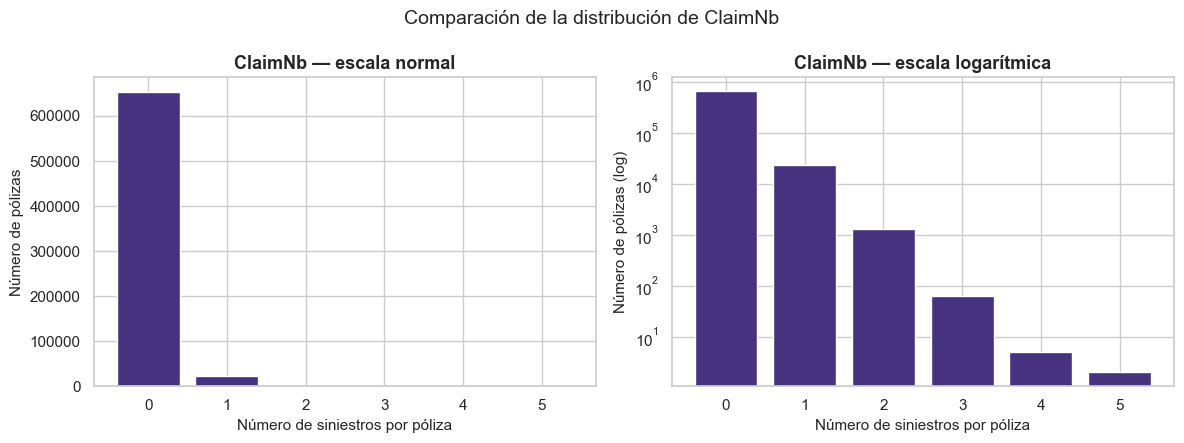

In [21]:
freq_claim = df_freq["ClaimNb"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Escala normal
axes[0].bar(freq_claim.index.astype(str), freq_claim.values)
axes[0].set_title("ClaimNb — escala normal")
axes[0].set_xlabel("Número de siniestros por póliza")
axes[0].set_ylabel("Número de pólizas")

# Escala logarítmica
axes[1].bar(freq_claim.index.astype(str), freq_claim.values)
axes[1].set_yscale("log")
axes[1].set_title("ClaimNb — escala logarítmica")
axes[1].set_xlabel("Número de siniestros por póliza")
axes[1].set_ylabel("Número de pólizas (log)")

plt.suptitle("Comparación de la distribución de ClaimNb", fontsize=14)
plt.tight_layout()
plt.show()

La variable ClaimNb presenta una distribución muy concentrada en cero. El 96.32% de las pólizas no registra ningún siniestro, mientras que solo el 3.48% presenta un siniestro y una proporción mucho menor presenta dos o más. Esto muestra que tener varios siniestros durante el período observado es poco común.

Al comparar ambas escalas, se puede ver que en la escala normal la categoría 0 domina el gráfico y dificulta observar las categorías menos frecuentes. Por esto, se utiliza la escala logarítmica únicamente para la visualización, ya que permite apreciar mejor las diferencias entre las categorías con pocos registros.

En general, este comportamiento es importante para el análisis de frecuencia, ya que se trata de una variable de conteo con una alta concentración de valores en cero. Además, será necesario considerar Exposure en las etapas posteriores, debido a que las pólizas no necesariamente estuvieron expuestas al riesgo durante el mismo período.

### 5. Identificación descriptiva de valores extremos

En esta sección se revisan de forma descriptiva los posibles valores extremos presentes en las principales variables numéricas. Para identificarlos se utiliza la regla de 1.5 veces el rango intercuartílico (RIC), considerando como potencialmente atípicas las observaciones que se encuentran por fuera de este rango.

In [22]:
def contar_atipicos_iqr(serie, k=1.5):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inf, limite_sup = q1 - k * iqr, q3 + k * iqr
    n_atipicos = int(((serie < limite_inf) | (serie > limite_sup)).sum())
    return pd.Series({
        "limite_inferior": limite_inf,
        "limite_superior": limite_sup,
        "n_atipicos_iqr": n_atipicos,
        "%_atipicos": round(n_atipicos / len(serie) * 100, 3),
    })

variables_a_revisar = {
    "VehAge": df_freq["VehAge"],
    "DrivAge": df_freq["DrivAge"],
    "BonusMalus": df_freq["BonusMalus"],
    "Density": df_freq["Density"],
    "ClaimAmount": df_sev["ClaimAmount"],
}

pd.DataFrame({nombre: contar_atipicos_iqr(serie) for nombre, serie in variables_a_revisar.items()}).T


,limite_inferior,limite_superior,n_atipicos_iqr,%_atipicos
VehAge,-11.5000,24.5000,"3,114.0000",0.4590
DrivAge,2.5000,86.5000,"1,275.0000",0.1880
BonusMalus,29.0000,85.0000,"62,384.0000",9.2010
Density,"-2,257.0000","4,007.0000","77,566.0000",11.4400
ClaimAmount,-146.3838,"2,242.0063","3,754.0000",15.0530


**Interpretación.** 

La regla de 1.5×RIC identifica diferentes cantidades de valores potencialmente atípicos dependiendo de la variable. En VehAge se identifican 3.114 observaciones (0.46%) por encima del límite superior de 24.5 años, mientras que en DrivAge son 1.275 (0.19%) por encima de los 86.5 años. En ambos casos representan una proporción pequeña de la muestra.

En BonusMalus se identifican 62.384 observaciones (9.21%) fuera del rango definido por la regla, mientras que en Density se encuentran 77.566 (11.44%). ClaimAmount presenta la mayor proporción de posibles valores atípicos, con 3.754 observaciones (15.05%), lo cual es consistente con la fuerte asimetría observada en la distribución de los montos de los siniestros.

Estos resultados muestran que la regla de 1.5×RIC marca una cantidad importante de observaciones como potencialmente atípicas, especialmente en Density, BonusMalus y ClaimAmount. Sin embargo, esto no significa que sean errores: en variables como densidad poblacional y montos de siniestros es normal encontrar valores altos. Por esta razón, los valores identificados se conservarán por ahora y su tratamiento se decidirá posteriormente durante el preprocesamiento.


### 6. Hallazgos principales

1. Las variables numéricas presentan comportamientos diferentes. Mientras que VehPower está más concentrada en algunos valores específicos, VehAge, DrivAge, BonusMalus y especialmente Density presentan diferentes niveles de asimetría.

2. Exposure se encuentra dentro del rango esperado entre 0 y 1, con una concentración importante de pólizas cercanas a una exposición de un año.

3. ClaimNb muestra una fuerte concentración en cero: la gran mayoría de las pólizas no presenta siniestros, mientras que los casos con varios siniestros son poco frecuentes. Esto confirma el comportamiento esperado de una variable de frecuencia en seguros.

4. ClaimAmount presenta una fuerte asimetría hacia la derecha. La mayoría de los siniestros tienen montos relativamente bajos, pero existen algunos casos con valores muy altos que generan una cola larga en la distribución.

5. Las variables categóricas Area, VehGas, VehBrand y Region tienen una cantidad de categorías manejable, aunque algunas presentan una mayor concentración de pólizas en determinadas categorías.

6. La revisión de valores extremos permitió identificar posibles outliers principalmente en VehAge, DrivAge, BonusMalus, Density y ClaimAmount. Estos valores no se consideran automáticamente errores y serán revisados con mayor detalle en la etapa de preprocesamiento.

### 7. Tratamiento de valores faltantes
En este dataset no se realizará ningún tratamiento para valores faltantes debido a que no existe ningún dato nulo en las variables. Asimismo, se decide conservar la totalidad de las observaciones atípicas sin eliminarlas ni acotarlas, dado que no corresponden a errores de digitación sino a condiciones raras pero completamente reales del contexto francés y del sector asegurador. Por un lado, en Francia no existe un límite de edad para conducir, lo que explica la presencia legitima de conductores mayores en DrivAge. Por otro lado, la población en Francia se concentra en muy pocas zonas altamente pobladas, por lo que residir en ellas convierte la variable Density en un valor atípico alto de forma natural. De igual forma, en VehAge los valores extremos responden a vehículos antiguos o autos clásicos que se mantienen asegurados y superan los 20 años de antigüedad. Finalmente, en ClaimAmount es perfectamente posible que la aseguradora haya pagado sumas muy grandes por indemnizaciones o vehículos costosos, lo cual representa un evento poco frecuente pero totalmente válido en la siniestralidad de responsabilidad civil.

### 8. Conclusiones

El análisis univariado permitió conocer el comportamiento individual de las variables del conjunto de datos freMTPL2 y encontrar algunas características importantes antes de avanzar con el análisis. Se identificaron diferencias en las distribuciones, una alta concentración de pólizas sin siniestros y una fuerte asimetría en los montos de los siniestros. También se identificaron algunos valores potencialmente atípicos que deberán revisarse posteriormente.

Estos resultados sirven como punto de partida para las siguientes etapas del proyecto, donde se analizarán las relaciones entre las variables y la siniestralidad. Posteriormente, se realizará el preprocesamiento de los datos y la construcción de los modelos de frecuencia, severidad y prima pura. 
